# A3: Transformers

In today's assignment, we will take a look at ViT (the vision transformer). Some of the material in this
lab comes from the following online sources:

- https://towardsdatascience.com/implementing-visualttransformer-in-pytorch-184f9f16f632
- https://github.com/lucidrains/vit-pytorch#vision-transformer---pytorch
- https://medium.com/mlearning-ai/vision-transformers-from-scratch-pytorch-a-step-by-step-guide-96c3313c2e0c

PS. if you would like to learn more on how to implement transformers from scratch, please take a look at 
- https://medium.com/the-dl/transformers-from-scratch-in-pytorch-8777e346ca51
- https://towardsdatascience.com/how-to-code-the-transformer-in-pytorch-24db27c8f9ec

<img src="img/optimus_prime.jpg" title="Transformer" style="width: 600px;" />

(The above photo needs a credit!)

## Vision Transformer (ViT)

The Vision Transformer (ViT) is a transformer targeted at vision processing tasks. It has achieved state-of-the-art performance in image classification and (with some modification) other tasks. The ViT concept for image classification is as follows:

<img src="img/vit.gif" title="ViT" />

### How does ViT work?

The steps of ViT are as follows:

1. Split input image into patches
2. Flatten the patches
3. Produce linear embeddings from the flattened patches
4. Add position embeddings
5. Feed the sequence preceeded by a `[class]` token as input to a standard transformer encoder
6. Pretrain the model to ouptut image labels for the `[class]` token (fully supervised on a huge dataset such as ImageNet-22K)
7. Fine-tune on the downstream dataset for the specific image classification task

### ViT architecture

ViT is a Transformer encoder. In detail, it looks like this:

<img src="img/ViTArchitecture.png" title="ViT architecture" />

In the figure we see four main parts:
<ol style="list-style-type:lower-alpha">
    <li> The high-level architecture of the model.</li>
    <li> The Transformer module.</li>
    <li> The multiscale self-attention (MSA) head.</li>
    <li> An individual self-attention (SA) head.</li>
</ol>

### Let's start

Let's do a small scale implementation with the MNIST dataset. The
code here is based on [Brian Pulfer's paper reimplementation repository](https://github.com/BrianPulfer/PapersReimplementations).

In [1]:
import numpy as np

import torch
import torch.nn as nn
from torch.nn import CrossEntropyLoss
from torch.optim import Adam
from torch.utils.data import DataLoader

from torchvision.datasets.mnist import MNIST
from torchvision.transforms import ToTensor

Import the MNIST dataset:

In [2]:
# Loading data
transform = ToTensor()

from torchvision import datasets

# mnist = datasets.MNIST(root='./data', download=True)


# train_set = MNIST(root='./../datasets', train=True, download=True, transform=transform)
# test_set = MNIST(root='./../datasets', train=False, download=True, transform=transform)


# Download and load training dataset
train_dataset = datasets.MNIST(
    root='../../../data', 
    train=True,  # True for training set
    download=True, 
    transform=transform
)

# Download and load test dataset
test_dataset = datasets.MNIST(
    root='../../../data', 
    train=False,  # False for test set
    download=True, 
    transform=transform
)

train_loader = DataLoader(train_dataset, shuffle=True, batch_size=16)
test_loader = DataLoader(test_dataset, shuffle=False, batch_size=16)

### Train and test functions

Next, let's create the train and test functions:

In [3]:
def train_ViT_classify(model, optimizer, N_EPOCHS, train_loader, device="cpu"):
    criterion = CrossEntropyLoss()
    for epoch in range(N_EPOCHS):
        train_loss = 0.0
        for batch in train_loader:
            x, y = batch
            x = x.to(device)
            y = y.to(device)
            y_hat = model(x)
            loss = criterion(y_hat, y) / len(x)

            train_loss += loss.item()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        print(f"Epoch {epoch + 1}/{N_EPOCHS} loss: {train_loss:.2f}")
        
def test_ViT_classify(model, optimizer, test_loader):
    criterion = CrossEntropyLoss()
    correct, total = 0, 0
    test_loss = 0.0
    for batch in test_loader:
        x, y = batch
        x = x.to(device)
        y = y.to(device)
        
        y_hat = model(x)
        loss = criterion(y_hat, y) / len(x)
        test_loss += loss

        correct += torch.sum(torch.argmax(y_hat, dim=1) == y).item()
        total += len(x)
    print(f"Test loss: {test_loss:.2f}")
    print(f"Test accuracy: {correct / total * 100:.2f}%")

### Multi-head Self Attention (MSA) Model

As with the basic transformer above, to build the ViT model, we need to create a MSA module and put it
together with the other elements.

For a single image, self attention means that each patch's representation
is updated based on its input token's similarity with those of the other patches.
As before, we perform a linear mapping of each patch to three distinct vectors $q$, $k$, and $v$ (query, key, value).

For each patch, we need to compute the dot product of its $q$ vector with all of the $k$ vectors, divide by the square root of the dimension
of the vectors, then apply softmax to the result. The resulting matrix is called the matrix of attention cues.
We multiply the attention cues with the $v$ vectors associated with the different input tokens and sum them all up.

The input for each patch is transformed to a new value based on its similarity (after the linear mapping to $q$, $k$, and $v$) with other patches.

However, the whole procedure is carried out $H$ times on $H$ sub-vectors of our current 8-dimensional patches, where $H$ is the number of heads.

Once all results are obtained, they are concatenated together then passed through a linear layer.

The MSA model looks like this:

In [4]:
class MSA(nn.Module):
    def __init__(self, d, n_heads=2):
        super(MSA, self).__init__()
        self.d = d
        self.n_heads = n_heads

        assert d % n_heads == 0, f"Can't divide dimension {d} into {n_heads} heads"

        d_head = int(d / n_heads)
        # Embeddings for q, k, and v. We use Sequential just so the list
        # is registered as a module belonging to this module so that parameters
        # get mapped to the correct device.
        self.q_mappings = nn.Sequential(*[nn.Linear(d_head, d_head) for _ in range(self.n_heads)])
        self.k_mappings = nn.Sequential(*[nn.Linear(d_head, d_head) for _ in range(self.n_heads)])
        self.v_mappings = nn.Sequential(*[nn.Linear(d_head, d_head) for _ in range(self.n_heads)])
        self.d_head = d_head
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, sequences):
        # Sequences has shape (N, seq_length, token_dim)
        # We go into shape    (N, seq_length, n_heads, token_dim / n_heads)
        # And come back to    (N, seq_length, item_dim)  (through concatenation)
        result = []
        for sequence in sequences:
            seq_result = []
            for head in range(self.n_heads):
                q_mapping = self.q_mappings[head]
                k_mapping = self.k_mappings[head]
                v_mapping = self.v_mappings[head]

                seq = sequence[:, head * self.d_head: (head + 1) * self.d_head]
                q, k, v = q_mapping(seq), k_mapping(seq), v_mapping(seq)

                attention = self.softmax(q @ k.T / (self.d_head ** 0.5))
                seq_result.append(attention @ v)
            result.append(torch.hstack(seq_result))
        return torch.cat([torch.unsqueeze(r, dim=0) for r in result])

**Note**: for each head, we create distinct Q, K, and V mapping functions (square matrices of size 4x4 in our example).

Since our inputs will be sequences of size (N, 50, 8), and we only use 2 heads, we will at some point have an (N, 50, 2, 4) tensor, use a nn.Linear(4, 4) module on it, and then come back, after concatenation, to an (N, 50, 8) tensor.

### Position encoding

The position encoding allows the model to understand where each patch is in the original image. While it is theoretically possible to learn
such positional embeddings, the original Vaswani et al. Transformer uses a fixed position embedding representation that adds
low-frequency values to the first dimension and higher-frequency values to the later dimensions, resulting in a code that is
more similar for nearby tokens than far away tokens. For each token, we add to its j-th coordinate the value

$$ p_{i,j} =
\left\{\begin{matrix}
\sin (\frac{i}{10000^{j/d_{embdim}}})\\ 
\cos (\frac{i}{10000^{j/d_{embdim}}})
\end{matrix}\right.
$$

We can visualize the position encoding matrix thusly:

<img src="img/peimages.png" title="" style="width: 800px;" />

Here is an implementation:

In [5]:
def get_positional_embeddings(sequence_length, d, device="cpu"):
    result = torch.ones(sequence_length, d)
    for i in range(sequence_length):
        for j in range(d):
            result[i][j] = np.sin(i / (10000 ** (j / d))) if j % 2 == 0 else np.cos(i / (10000 ** ((j - 1) / d)))
    return result.to(device)

### ViT Model

Create the ViT model as below. The explaination is later.

In [6]:
class ViT(nn.Module):
    def __init__(self, input_shape, n_patches=7, hidden_d=8, n_heads=2, out_d=10):
        # Super constructor
        super(ViT, self).__init__()

        # Input and patches sizes
        self.input_shape = input_shape
        self.n_patches = n_patches
        self.n_heads = n_heads
        assert input_shape[1] % n_patches == 0, "Input shape not entirely divisible by number of patches"
        assert input_shape[2] % n_patches == 0, "Input shape not entirely divisible by number of patches"
        self.patch_size = (input_shape[1] / n_patches, input_shape[2] / n_patches)
        self.hidden_d = hidden_d

        # 1) Linear mapper
        self.input_d = int(input_shape[0] * self.patch_size[0] * self.patch_size[1])
        self.linear_mapper = nn.Linear(self.input_d, self.hidden_d)

        # 2) Classification token
        self.class_token = nn.Parameter(torch.rand(1, self.hidden_d))

        # 3) Positional embedding
        # (In forward method)

        # 4a) Layer normalization 1
        self.ln1 = nn.LayerNorm((self.n_patches ** 2 + 1, self.hidden_d))

        # 4b) Multi-head Self Attention (MSA) and classification token
        self.msa = MSA(self.hidden_d, n_heads)

        # 5a) Layer normalization 2
        self.ln2 = nn.LayerNorm((self.n_patches ** 2 + 1, self.hidden_d))

        # 5b) Encoder MLP
        self.enc_mlp = nn.Sequential(
            nn.Linear(self.hidden_d, self.hidden_d),
            nn.ReLU()
        )

        # 6) Classification MLP
        self.mlp = nn.Sequential(
            nn.Linear(self.hidden_d, out_d),
            nn.Softmax(dim=-1)
        )

    def forward(self, images):
        # Dividing images into patches
        n, c, w, h = images.shape
        patches = images.reshape(n, self.n_patches ** 2, self.input_d)

        # Running linear layer for tokenization
        tokens = self.linear_mapper(patches)

        # Adding classification token to the tokens
        tokens = torch.stack([torch.vstack((self.class_token, tokens[i])) for i in range(len(tokens))])

        # Adding positional embedding
        tokens += get_positional_embeddings(self.n_patches ** 2 + 1, self.hidden_d, device).repeat(n, 1, 1)

        # TRANSFORMER ENCODER BEGINS ###################################
        # NOTICE: MULTIPLE ENCODER BLOCKS CAN BE STACKED TOGETHER ######
        # Running Layer Normalization, MSA and residual connection
        out = tokens + self.msa(self.ln1(tokens))

        # Running Layer Normalization, MLP and residual connection
        out = out + self.enc_mlp(self.ln2(out))
        # TRANSFORMER ENCODER ENDS   ###################################

        # Getting the classification token only
        out = out[:, 0]

        return self.mlp(out)

#### Step 1: Patchifying and the linear mapping

The transformer encoder was developed with sequence data in mind, such as English sentences. However, an image is not a sequence. Thus, we break it into multiple sub-images and map each sub-image to a vector.

We do so by simply reshaping our input, which has size $(N, C, H, W)$ (in our example $(N, 1, 28, 28)$), to size (N, #Patches, Patch dimensionality), where the dimensionality of a patch is adjusted accordingly.

In MNIST, we break each $(1, 28, 28)$ into 7x7 patches (hence, each of size 4x4). That is, we are going to obtain 7x7=49 sub-images out of a single image.

$$(N,1,28,28) \rightarrow (N,P\times P, H \times C/P  \times W \times C/P) \rightarrow (N, 7\times 7, 4\times 4) \rightarrow (N, 49, 16)$$

<img src="img/patch.png" title="an image is split into patches" />

#### Step 2: Adding the classification token

When information about all other tokens will be present here, we will be able to classify the image using only this special token. The initial value of the special token (the one fed to the transformer encoder) is a parameter of the model that needs to be learned.

We can now add a parameter to our model and convert our (N, 49, 8) tokens tensor to an (N, 50, 8) tensor (we add the special token to each sequence).

Passing from (N,49,8) → (N,50,8) is probably sub-optimal. Also, notice that the classification token is put as the first token of each sequence. This will be important to keep in mind when we will then retrieve the classification token to feed to the final MLP.

#### Step 3: Positional encoding

See above, as we mentioned.

#### Step 4: LN, MSA, and Residual Connection

The step is to apply layer normalization to the tokens, then apply MSA, and add a residual connection (add the input we had before applying LN).
- **Layer normalization** is a popular block that, given an input, subtracts its mean and divides by the standard deviation.
- **MSA**: same as the vanilla transformer.
- **A residual connection** consists in just adding the original input to the result of some computation. This, intuitively, allows a network to become more powerful while also preserving the set of possible functions that the model can approximate.

The residual connection is added at the original (N, 50, 8) tensor to the (N, 50, 8) obtained after LN and MSA.

#### Step 5: LN, MLP, and Residual Connection
All that is left to the transformer encoder is just a simple residual connection between what we already have and what we get after passing the current tensor through another LN and an MLP.

#### Step 6: Classification MLP
Finally, we can extract just the classification token (first token) out of our N sequences, and use each token to get N classifications.
Since we decided that each token is an 8-dimensional vector, and since we have 10 possible digits, we can implement the classification MLP as a simple 8x10 matrix, activated with the SoftMax function.

The output of our model is now an (N, 10) tensor.

In [7]:
device = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")
print(device)

cuda:2


In [8]:
model = ViT((1, 28, 28), n_patches=7, hidden_d=20, n_heads=2, out_d=10)
model = model.to(device)

N_EPOCHS = 5
LR = 0.01
optimizer = Adam(model.parameters(), lr=LR)

In [9]:
train_ViT_classify(model, optimizer, N_EPOCHS, train_loader, device)

Epoch 1/10 loss: 426.00
Epoch 2/10 loss: 416.18
Epoch 3/10 loss: 445.17
Epoch 4/10 loss: 490.03
Epoch 5/10 loss: 426.15
Epoch 6/10 loss: 423.82
Epoch 7/10 loss: 469.76
Epoch 8/10 loss: 457.58
Epoch 9/10 loss: 440.10
Epoch 10/10 loss: 453.73


In [10]:
test_ViT_classify(model, optimizer, test_loader)

Test loss: 74.07
Test accuracy: 56.48%


## Pytorch ViT

For a full implementation of ViT
in PyTorch, we can use the
[vit-pytorch package](https://github.com/lucidrains/vit-pytorch#vision-transformer---pytorch).

In [ ]:
!pip install vit-pytorch

### ViT Pytorch implementation

In [11]:
import torch
from vit_pytorch import ViT

v = ViT(
    image_size = 256,
    patch_size = 32,
    num_classes = 1000,
    dim = 1024,
    depth = 6,
    heads = 16,
    mlp_dim = 2048,
    dropout = 0.1,
    emb_dropout = 0.1
)

img = torch.randn(1, 3, 256, 256)

preds = v(img) # (1, 1000)

The implementation also contains a distillable ViT:

In [12]:
import torch
from torchvision.models import resnet50

from vit_pytorch.distill import DistillableViT, DistillWrapper

teacher = resnet50(pretrained = True)

v = DistillableViT(
    image_size = 256,
    patch_size = 32,
    num_classes = 1000,
    dim = 1024,
    depth = 6,
    heads = 8,
    mlp_dim = 2048,
    dropout = 0.1,
    emb_dropout = 0.1
)

distiller = DistillWrapper(
    student = v,
    teacher = teacher,
    temperature = 3,           # temperature of distillation
    alpha = 0.5,               # trade between main loss and distillation loss
    hard = False               # whether to use soft or hard distillation
)

img = torch.randn(2, 3, 256, 256)
labels = torch.randint(0, 1000, (2,))

loss = distiller(img, labels)
loss.backward()

# after lots of training above ...

pred = v(img) # (2, 1000)

/home/jupyter-dsai-st123175/rtml_env/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/jupyter-dsai-st123175/rtml_env/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


and so on...

## Fine Tuning Torchvision ViT on Kaggle Sports Dataset

We will use pretrained ViT(ViT base 16) model from torchvision to fine-tune on Kaggle sports-classification dataset. The detail description of the dataset and download link is given below.  

Dataset Url:  
https://www.kaggle.com/datasets/gpiosenka/sports-classification?resource=download

The objectives are the following:  
- To get fine-tuning experience from a medium large dataset.  
- To effectively use the resources and hyperparameters such as batch size and learning rate.  
- To get a knowledge on how to build your own custom dataset class.  
- To obtain experience on minor but very useful python libraries such as tqdm, tensorboardX and matplotlib for visualization as well as tracking your training.
- To gain your achievement on improving model performance with Vision Transformer.


### Load the pretrained model

In [13]:
import torch
import torch.nn as nn
from torchvision.models import vit_b_16 as ViT, ViT_B_16_Weights
model = ViT(weights=ViT_B_16_Weights.DEFAULT)

# Count trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print(f"{total_params/1000000}M")

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

### Change the classifier head

The original ViT is trained on ImageNet dataset with 1,000 classes. We have to change it to our sport-classification dataset output which has 100 classes.

In [14]:
# Changed to out_features = 100
model.heads = nn.Sequential(nn.Linear(in_features=768, out_features=100, bias=True))

# Set the GPU Device
device = 'cuda:1' if torch.cuda.is_available() else 'cpu'
print(device)

# Move the model to Device
model.to(device)
print("Classifier Head: ", model.heads)
# Initiate the weights and biases
for m in model.heads:
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            nn.init.normal_(m.bias, std=1e-6)
    # print(m.weight)
    # print(m.bias)

cuda:1
Classifier Head:  Sequential(
  (0): Linear(in_features=768, out_features=100, bias=True)
)


### Custom dataset class
dataset.py

In [15]:
from torch.utils.data import Dataset
import torch
import cv2 # requires !pip3 install opencv-python
import os
import pandas as pd
from skimage import io



class SportDataset(Dataset):
    """Sport dataset."""

    def __init__(self, csv_file, root_dir, class_file, train=True, transform=None):
        """
        Args:
            csv_file (string): Path to the csv file with annotations.
            class_file (string): Path to the csv file with class names and indices.
            root_dir (string): Directory with all the images.
            transform (callable, optional): Optional transform to be applied
                on a sample.
        """
        classes = pd.read_csv(class_file)
        self.class_dict = {row[2]:row[0] for i, row in classes.iterrows()}

        df = pd.read_csv(csv_file)
        df.drop(index=5621, inplace=True)
        
        if train:
            self.df = df[df['data set'] == 'train']
        else:
            self.df = df[df['data set'] == 'valid']

        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        img_name = os.path.join(self.root_dir,
                                self.df.iloc[idx, 1])
        image = io.imread(img_name)

        if image.shape[-1] != 3:
            image = cv2.cvtColor(image,cv2.COLOR_GRAY2RGB)

        if self.transform:
            image = self.transform(image)

        label_keys = self.df.iloc[idx, 2]
        labels = self.class_dict[label_keys]
        labels = float(labels)

        sample = {'image': image, 'labels': labels}

        return sample

### Dataset Directories

In [16]:
# csv_file = '/your/sport/dataset/directory/location/sports.csv'
# class_file = '/your/sport/dataset/directory/location/sports.csv'
# root_dir = '/your/sport/dataset/directory/

csv_file = '/home/jupyter-dsai-st123175/dataset_sport/sports.csv'
class_file = '/home/jupyter-dsai-st123175/dataset_sport/sports.csv'
root_dir = '/home/jupyter-dsai-st123175/dataset_sport/'


Utils.py

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import torch


# Helper function for inline image display
def matplotlib_imshow(img, one_channel=False):
    if one_channel:
        img = img.mean(dim=0)
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    if one_channel:
        plt.imshow(npimg, cmap="Greys")
    else:
        plt.imshow(np.transpose(npimg, (1, 2, 0)))

### Data loader and visualize image
This script cannot be run if you are not using jupyter notebook (for eg. ssh). Another option is save the image and view in your local machine.

/tmp/ipykernel_2540/2331788022.py:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  self.class_dict = {row[2]:row[0] for i, row in classes.iterrows()}
/tmp/ipykernel_2540/2331788022.py:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  self.class_dict = {row[2]:row[0] for i, row in classes.iterrows()}
/tmp/ipykernel_2540/132951541.py:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  class_dict = { row[0]:row[1] for i, row in class_df

class dict:  {0: 'valid/air hockey/5.jpg', 1: 'valid/ampute football/5.jpg', 2: 'valid/archery/5.jpg', 3: 'valid/arm wrestling/5.jpg', 4: 'valid/axe throwing/5.jpg', 5: 'valid/balance beam/5.jpg', 6: 'valid/barell racing/5.jpg', 7: 'valid/baseball/5.jpg', 8: 'valid/basketball/5.jpg', 9: 'valid/baton twirling/5.jpg', 10: 'valid/bike polo/5.jpg', 11: 'valid/billiards/5.jpg', 12: 'valid/bmx/5.jpg', 13: 'valid/bobsled/5.jpg', 14: 'valid/bowling/5.jpg', 15: 'valid/boxing/5.jpg', 16: 'valid/bull riding/5.jpg', 17: 'valid/bungee jumping/5.jpg', 18: 'valid/canoe slamon/5.jpg', 19: 'valid/cheerleading/5.jpg', 20: 'valid/chuckwagon racing/5.jpg', 21: 'valid/cricket/5.jpg', 22: 'valid/croquet/5.jpg', 23: 'valid/curling/5.jpg', 24: 'valid/disc golf/5.jpg', 25: 'valid/fencing/5.jpg', 26: 'valid/field hockey/5.jpg', 27: 'valid/figure skating men/5.jpg', 28: 'valid/figure skating pairs/5.jpg', 29: 'valid/figure skating women/5.jpg', 30: 'valid/fly fishing/5.jpg', 31: 'valid/football/5.jpg', 32: 'vali

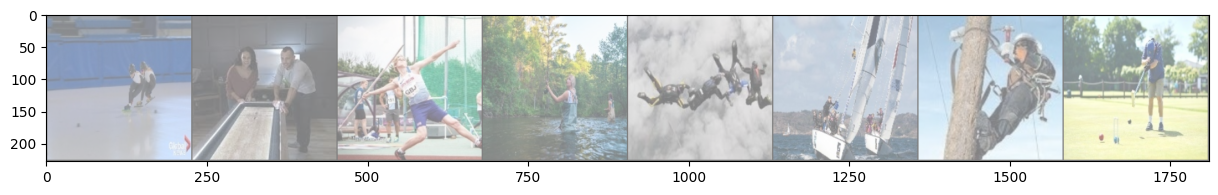

In [18]:
# from dataset import SportDataset
# from utils import matplotlib_imshow
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision
import pandas as pd


train_transform = transforms.Compose(
    [
    transforms.ToPILImage(mode='RGB'),
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ToTensor()
    ]
)

val_transform = transforms.transforms.Compose(
    [
    transforms.ToPILImage(mode='RGB'),
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor()
    ]
)

train_ds = SportDataset(csv_file=csv_file, class_file=class_file, root_dir=root_dir, train=True, transform=train_transform)
val_ds = SportDataset(csv_file=csv_file, class_file=class_file, root_dir=root_dir, train=False, transform=val_transform)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False)

class_df = pd.read_csv(class_file, usecols=['class id', 'filepaths', 'labels', 'data set'])
class_dict = { row[0]:row[1] for i, row in class_df.iterrows()}
print("class dict: ", class_dict)

dataiter = iter(train_loader)
data = next(dataiter)

plt.rcParams['figure.figsize'] = [15, 5]
# Create a grid from the images and show them
img_grid = torchvision.utils.make_grid(data['image'])
matplotlib_imshow(img_grid, one_channel=False)
print(','.join(class_dict[data['labels'][j].item()] for j in range(8)))


### TensorboardX for Logging
logger.py

In [19]:
from tensorboardX import SummaryWriter # have to install pip3 install tensorboardX
import torch
import os
import errno


class Logger:
    def __init__(self, model_name, data_name):
        self.model_name = model_name
        self.data_name = data_name

        self.comment = f'{model_name}_{data_name}'
        self.data_subdir = f'{model_name}/{data_name}'

        self.writer = SummaryWriter(comment=self.comment)


    def loss_log(self, train_loss, val_loss, nth_epoch):
        self.writer.add_scalars(
            'Train vs Val Loss',
            {'Training': train_loss, 'Validation': val_loss},
            nth_epoch
        )
        
    def acc_log(self, train_acc, val_acc, nth_epoch):
        self.writer.add_scalars(
            'Train vs Val Accuracy',
            {'Training': train_acc, 'Validation': val_acc},
            nth_epoch
        )

    def save_models(self, model, nth_epoch):
        out_dir = f'saved/{self.model_name}'
        Logger._make_dir(out_dir)
        torch.save(
            model.state_dict(),
            f'{out_dir}/Ep.{nth_epoch}.pth'
        )

    def close(self):
        self.writer.close()

    @staticmethod
    def _make_dir(directory):
        try:
            os.makedirs(directory)
        except OSError as e:
            if e.errno != errno.EEXIST:
                raise

    @staticmethod
    def _step(epoch):
        pass


### Hyperparameters and Loss Function
train.py

In [20]:
import pandas as pd
import time
from tqdm import tqdm
import torch
import torch.nn as nn
from torchvision.models.vision_transformer import vit_b_16 as ViT, ViT_B_16_Weights
from torchvision import transforms
from torch.utils.data import DataLoader
# from dataset import SportDataset
# from logger import Logger


lr = 1e-5
epoch_number = 0 # describe the starting epoch if you are continuing training
EPOCHS = 30 # number of epochs to train
model_name = 'vit_b16'
dataset_name = 'sport_dataset'

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)

In [21]:
logger = Logger(model_name, dataset_name)


best_vloss = 100000.
# timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
timestamp = time.time()

for epoch in range(EPOCHS):
    print('EPOCH {}:'.format(epoch_number + 1))
    since = time.time()
    # Make sure gradient tracking is on, and do a pass over the data
    model.train(True)
    running_loss = 0.
    last_loss = 0.
    running_acc = 0.
    train_loop = tqdm(train_loader)
    # Here, we use enumerate(training_loader) instead of
    # iter(training_loader) so that we can track the batch
    # index and do some intra-epoch reporting
    for i, data in enumerate(train_loop):
        # Every data instance is an input + label pair
        inputs, labels = data['image'].to(device), data['labels'].long().to(device)

        # Zero your gradients for every batch!
        optimizer.zero_grad()

        # Make predictions for this batch
        outputs = model(inputs)

        # Compute the loss and its gradients
        loss = loss_fn(outputs, labels)
        loss.backward()

        # print(labels.shape, outputs.shape)
        _, prediction = torch.max(outputs, dim=1)
        corrects = (labels == (prediction)).sum() / len(labels)
        running_acc += corrects

        # Adjust learning weights
        optimizer.step()

        # Gather data and report
        running_loss += loss.item()

        train_loop.set_postfix(loss=loss.item())

    avg_train_acc = running_acc/len(train_loader)
    avg_train_loss = running_loss/len(train_loader)

    print('Epoch {} loss: {}'.format(epoch_number+1, avg_train_loss))


    # We don't need gradients on to do reporting
    model.train(False)

    vloop = tqdm(val_loader)
    running_vloss = 0.0
    running_vacc = 0.0
    for i, data in enumerate(vloop):
        inputs, labels = data['image'].to(device), data['labels'].long().to(device)
        outputs = model(inputs)
        loss = loss_fn(outputs, labels)
        running_vloss += loss.item()

        _, prediction = torch.max(outputs, dim=1)

        corrects = (prediction == labels).sum() / len(labels)
        running_vacc += corrects

        vloop.set_postfix(loss=loss.item())

    avg_vloss = running_vloss / len(val_loader)
    print('LOSS train {} valid {}'.format(avg_train_loss, avg_vloss))

    avg_vacc = running_vacc / len(val_loader)
    print('Accuracy train {} valid {}'.format(avg_train_acc, avg_vacc))

    # Log the running loss averaged per batch
    # for both training and validation
    logger.loss_log( train_loss=avg_train_loss,
                    val_loss=avg_vloss, nth_epoch=epoch_number+1)

    logger.acc_log( train_acc=avg_train_acc,
                    val_acc=avg_vacc, nth_epoch=epoch_number+1)

    # Track best performance, and save the model's state
    if avg_vloss < best_vloss:
        best_vloss = avg_vloss
        model_path = 'model_{}_{}'.format(timestamp, epoch_number+1)
        logger.save_models(model=model, nth_epoch=epoch_number+1)

    ep_duration = time.time() - since
    print("Epoch time taken: {:.0f}m {:.0f}s".format(ep_duration // 60, ep_duration % 60))
    epoch_number += 1

total_time = time.time() - timestamp
print("Total time taken: {:.0f}m {:.0f}s".format(total_time // 60, total_time % 60))

# GPU 3397MiB

EPOCH 1:


100%|██████████| 1687/1687 [07:01<00:00,  4.00it/s, loss=3.9] 


Epoch 1 loss: 4.6310275244020325


100%|██████████| 63/63 [00:15<00:00,  4.19it/s, loss=4.05]


LOSS train 4.6310275244020325 valid 4.386344769644359
Accuracy train 0.03037937358021736 valid 0.0674603208899498
Epoch time taken: 7m 25s
EPOCH 2:


...

LOSS train 0.14415813798982502 valid 0.2538830367109132
Accuracy train 0.9878482818603516 valid 0.9424603581428528
Epoch time taken: 4m 21s
EPOCH 30:


100%|██████████| 1687/1687 [04:25<00:00,  6.36it/s, loss=0.0786]


Epoch 30 loss: 0.13773695703664332


100%|██████████| 63/63 [00:06<00:00, 10.45it/s, loss=0.133] 


LOSS train 0.13773695703664332 valid 0.24541324146446727
Accuracy train 0.9894784092903137 valid 0.9424603581428528
Epoch time taken: 4m 32s
Total time taken: 130m 21s


## To do on your own

1. Manage your available resources and continue fine-tune on the same dataset. The pretrained weights at 7th epoch (accuracy = 70%%) is giving below link: (Hint: for batch_size = 8 on Puffer will used up 5GB of RAM in one GPU)

    https://drive.google.com/file/d/1Fewu2rhbqw99THDGPzDMPzgSu8J5iHfO/view?usp=sharing

    Feel free to download the file and continue fine-tuning with different settings. Make a challenge to achieve a better performance than my result (at 30th, I got 94%). There is no bound for the number of epochs to continue. (please don't forget to change the epoch_number=30)

2. With your final fine-tuned weights, try to inference and get the result on images from "test" and "images to predict" directories in sport_dataset. Visualize some random inferenced images with their predictions.

3. Describe your experience on fine-tuning and show the graphs.



### Solution
Q1: See above that is the configuration i used to achieve 94% at 30% on validation set and 96% on test set (See below)

Q2: See bellow

In [23]:
# I realized that my custom dataset class doesn't include test set so modified it accordingly

class SportDataset(Dataset):
    """Sport dataset."""

    def __init__(self, csv_file, root_dir, class_file, mode="train", transform=None):
        """
        Args:
            csv_file (string): Path to the csv file with annotations.
            class_file (string): Path to the csv file with class names and indices.
            root_dir (string): Directory with all the images.
            transform (callable, optional): Optional transform to be applied
                on a sample.
        """
        classes = pd.read_csv(class_file)
        self.class_dict = {row[2]:row[0] for i, row in classes.iterrows()}

        df = pd.read_csv(csv_file)
        df.drop(index=5621, inplace=True)
        
        if mode == "train":
            self.df = df[df['data set'] == 'train']
        elif mode == "valid":
            self.df = df[df['data set'] == 'valid']
        else:
            self.df = df[df['data set'] == 'test']

        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        img_name = os.path.join(self.root_dir,
                                self.df.iloc[idx, 1])
        image = io.imread(img_name)

        if image.shape[-1] != 3:
            image = cv2.cvtColor(image,cv2.COLOR_GRAY2RGB)

        if self.transform:
            image = self.transform(image)

        label_keys = self.df.iloc[idx, 2]
        labels = self.class_dict[label_keys]
        labels = float(labels)

        sample = {'image': image, 'labels': labels}

        return sample

csv_file = '/home/jupyter-dsai-st123175/dataset_sport/sports.csv'
class_file = '/home/jupyter-dsai-st123175/dataset_sport/sports.csv'
root_dir = '/home/jupyter-dsai-st123175/dataset_sport/'

# Define transform function of my test set
test_transform = transforms.transforms.Compose(
    [
    transforms.ToPILImage(mode='RGB'),
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor()
    ]
)


test_ds = SportDataset(csv_file=csv_file, class_file=class_file, root_dir=root_dir, mode="test", transform=test_transform)

test_loader = DataLoader(test_ds, batch_size=8, shuffle=False)

# We don't need gradients on to do reporting
model.train(False)

tloop = tqdm(test_loader)
running_tacc = 0.0
for i, data in enumerate(tloop):
    inputs, labels = data['image'].to(device), data['labels'].long().to(device)
    outputs = model(inputs)
    
    _, prediction = torch.max(outputs, dim=1)

    corrects = (prediction == labels).sum() / len(labels)
    running_tacc += corrects

    vloop.set_postfix(loss=loss.item())

avg_tacc = running_tacc / len(test_loader)
print('Accuracy test {}'.format(avg_tacc))


/tmp/ipykernel_2540/1082085455.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  self.class_dict = {row[2]:row[0] for i, row in classes.iterrows()}
100%|██████████| 63/63 [00:19<00:00,  3.18it/s]

Accuracy test 0.95634925365448


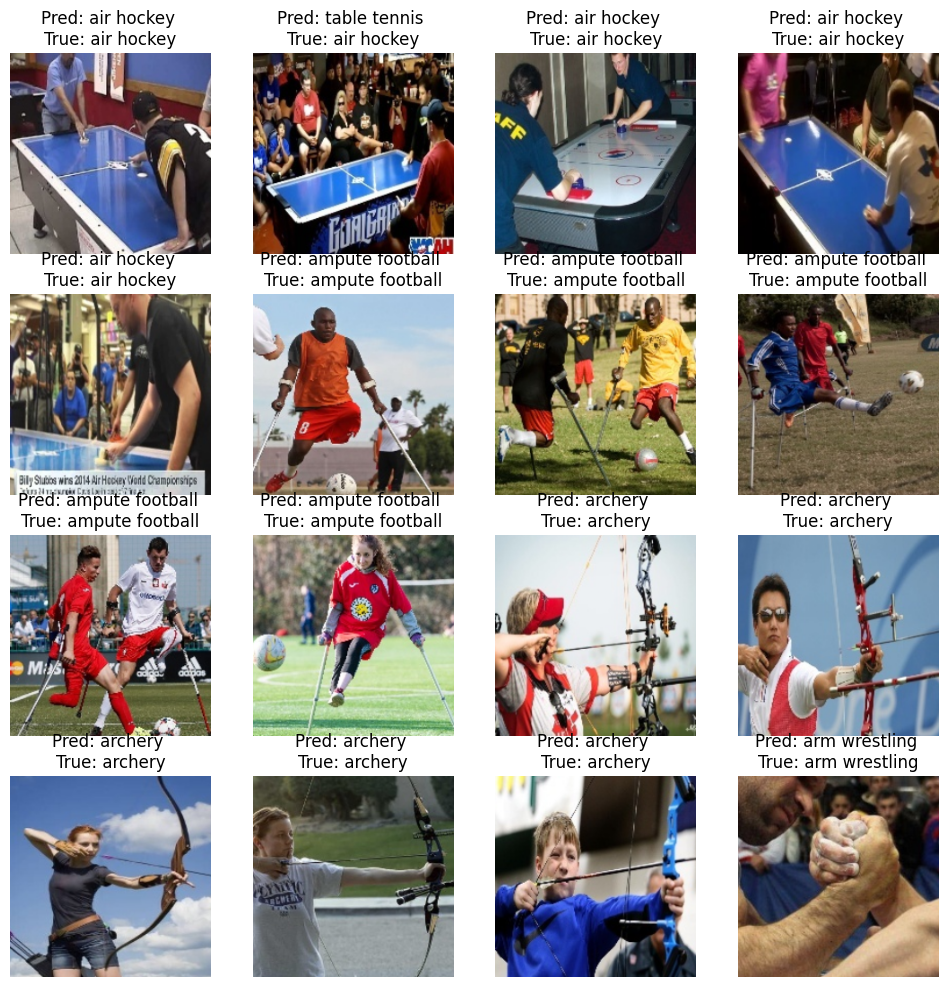

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import torchvision.utils as vutils

# Set model to evaluation mode
model.eval()

# Define a function to display images with predictions and true labels
def visualize_predictions(model, dataloader, class_dict, device, num_images=16):
    model.eval()
    images_shown = 0
    plt.figure(figsize=(12, 12))

    with torch.no_grad():
        for data in dataloader:
            inputs, labels = data['image'].to(device), data['labels'].long().to(device)
            outputs = model(inputs)
            _, predictions = torch.max(outputs, 1)

            for j in range(inputs.size(0)):
                if images_shown >= num_images:
                    break
                images_shown += 1
                
                plt.subplot(4, 4, images_shown)
                plt.axis('off')
                img = inputs[j].cpu().numpy().transpose((1, 2, 0))
                img = np.clip(img, 0, 1)
                plt.imshow(img)
                
                pred_class = list(class_dict.keys())[list(class_dict.values()).index(predictions[j].item())]
                true_class = list(class_dict.keys())[list(class_dict.values()).index(labels[j].item())]
                plt.title(f'Pred: {pred_class} \nTrue: {true_class}')
            
            if images_shown >= num_images:
                break
    plt.show()

# Visualize predictions
visualize_predictions(model, test_loader, test_ds.class_dict, device, num_images=16)
